# Credit card fraud — exploratory analysis

Goal: measure the imbalance and see how frauds differ from legitimate transactions.

In [1]:
from fraud_detection.data import load_dataset

X, y = load_dataset()
print(X.shape)
y.value_counts()

(284807, 29)


Class
0    284315
1       492
Name: count, dtype: int64

## Amounts by class

In [2]:
X.groupby(y)["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


## PCA components: largest mean differences between classes

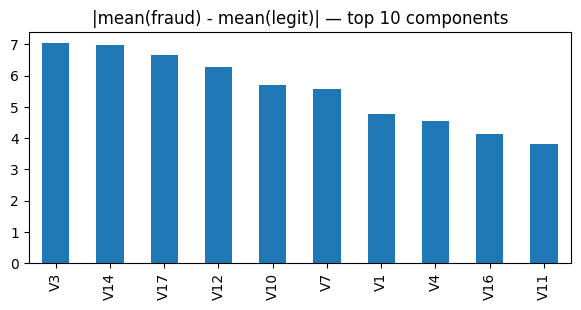

In [3]:
v = [c for c in X.columns if c.startswith("V")]
diff = (X[v][y == 1].mean() - X[v][y == 0].mean()).abs().sort_values(ascending=False).head(10)
diff.plot.bar(figsize=(7, 3), title="|mean(fraud) - mean(legit)| — top 10 components");

## Why accuracy is useless here

Predicting "legit" for every transaction is **99.83 % accurate** and catches zero fraud. We therefore use:
- **PR-AUC** (precision-recall area), which focuses on the rare positive class;
- a **decision threshold chosen by business cost** (missed fraud = 100 × false alert) instead of the default 0.5.

Note: OpenML's version of this dataset marks `Time` as an ignored attribute, so the models use the 28 PCA components plus `Amount`.